### Mini Project 1: Spatial and Temporal Analysis of Crime Incidents in Little Rock, Arkansas

1. Project Overview

This mini project examines the spatial and temporal distribution of reported crime incidents in Little Rock, Arkansas using incident-level crime data from 2020 to 2026. The purpose of this project is to build on prior coursework in spatial data processing, visualization, and analysis by developing a reproducible GIS workflow in Python. In addition to tabular and spatial analysis, this project also demonstrates how a cleaned and enriched geospatial dataset can be integrated with ArcGIS Online and the ArcGIS Python API for web-based mapping and sharing.

The project begins with a raw CSV dataset containing crime records and geographic coordinates. The dataset is transformed into a Pandas DataFrame, screened for missing values, cleaned for analysis, and converted into a GeoDataFrame for spatial mapping. Several derived indicators are created from the incident date and offense information in order to explore patterns by year, time of day, day of week, and offense type. The final cleaned GeoDataFrame is then exported and published to ArcGIS Online as a hosted feature layer. A web map is created from within the notebook using the ArcGIS Python API and saved for online sharing.

The broader goal of the project is to identify meaningful patterns in crime occurrence and to demonstrate an end-to-end GIS programming workflow that connects local data analysis with web GIS publishing.

2. Problem Statement


Crime is inherently spatial and temporal. Understanding when and where incidents occur can support urban planning, public safety analysis, and resource allocation. This project focuses on the following question:

What spatial and temporal patterns are evident in reported crime incidents in Little Rock, Arkansas between 2020 and 2026, and which offense categories appear most prominent in the dataset?

This problem is well suited for GIS analysis because the data include both location coordinates and timestamps. The spatial dimension allows the creation of point maps and web maps, while the temporal attributes support the development of summary indicators such as yearly counts, hourly trends, and day-of-week patterns. By combining exploratory analysis with web-based mapping, this project aims to move beyond simple point plotting and provide a more interpretable view of the crime dataset.

A secondary goal of the project is technical: to demonstrate how a GeoDataFrame created from a tabular data source can be cleaned, analyzed, and then published to ArcGIS Online using the ArcGIS Python API. This directly addresses the project requirement of integrating Python-based geospatial analysis with online GIS services.

### Import Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Read raw data once
crime_df_raw = pd.read_csv(r"D:\WesternMichiganUni\GIS_Programming\miniproject\Little_Rock_Crime_2020_2026.csv")

# Parse dates
crime_df_raw["INCIDENT_DATE"] = pd.to_datetime(crime_df_raw["INCIDENT_DATE"], errors="coerce")
crime_df_raw["Year"] = crime_df_raw["INCIDENT_DATE"].dt.year

# Remove incomplete year
crime_df = crime_df_raw[crime_df_raw["Year"] != 2026].copy()

# Clean city and state
crime_df["CITY_CLEAN"] = crime_df["CITY"].astype(str).str.upper().str.strip()
crime_df["STATE_CLEAN"] = crime_df["STATE"].astype(str).str.upper().str.strip()

# Keep likely Little Rock records only
crime_df = crime_df[
    crime_df["CITY_CLEAN"].str.contains("LITTLE ROCK", na=False) |
    (crime_df["CITY_CLEAN"] == "LR")
].copy()

crime_df = crime_df[crime_df["STATE_CLEAN"] == "AR"].copy()

# Remove missing coordinates
crime_df = crime_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# Optional rough coordinate filter
crime_df = crime_df[
    crime_df["LATITUDE"].between(34.55, 34.85) &
    crime_df["LONGITUDE"].between(-92.55, -92.15)
].copy()

# Create derived variables
crime_df["Month"] = crime_df["INCIDENT_DATE"].dt.month
crime_df["Month_Name"] = crime_df["INCIDENT_DATE"].dt.month_name()
crime_df["Hour"] = crime_df["INCIDENT_DATE"].dt.hour
crime_df["DayOfWeek"] = crime_df["INCIDENT_DATE"].dt.day_name()
crime_df["Is_Weapon_Reported"] = crime_df["WEAPON_TYPE"].notna()

def classify_offense(offense):
    offense = str(offense).upper()
    if "ASSAULT" in offense:
        return "Assault"
    elif "LARCENY" in offense or "THEFT" in offense:
        return "Theft"
    elif "BURGLARY" in offense:
        return "Burglary"
    elif "ROBBERY" in offense:
        return "Robbery"
    elif "MOTOR VEHICLE" in offense:
        return "Vehicle Crime"
    elif "RAPE" in offense or "SEX" in offense:
        return "Sex Offense"
    else:
        return "Other"

crime_df["Offense_Group"] = crime_df["OFFENSE_DESCRIPTION"].apply(classify_offense)

# Convert to GeoDataFrame
crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["LONGITUDE"], crime_df["LATITUDE"]),
    crs="EPSG:4326"
)

print("Final cleaned records:", len(crime_gdf))
print("Years included:", sorted(crime_gdf["Year"].dropna().unique()))

C:\Users\tangi\AppData\Local\Temp\ipykernel_39344\2534284056.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df_raw["INCIDENT_DATE"] = pd.to_datetime(crime_df_raw["INCIDENT_DATE"], errors="coerce")


Final cleaned records: 74806
Years included: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [3]:
county_gdf = gpd.read_file(r"D:\WesternMichiganUni\GIS_Programming\miniproject\COUNTY_BOUNDARY.shp").to_crs(crime_gdf.crs)

crime_gdf = gpd.sjoin(
    crime_gdf,
    county_gdf,
    how="inner",
    predicate="within"
)

print("Records after county filter:", len(crime_gdf))

Records after county filter: 74806


In [4]:
year_counts = crime_gdf["Year"].value_counts().sort_index()

In [5]:
top_offenses = crime_gdf["OFFENSE_DESCRIPTION"].value_counts().head(10)

In [6]:
hour_counts = crime_gdf["Hour"].value_counts().sort_index()

<Figure size 1000x1000 with 0 Axes>

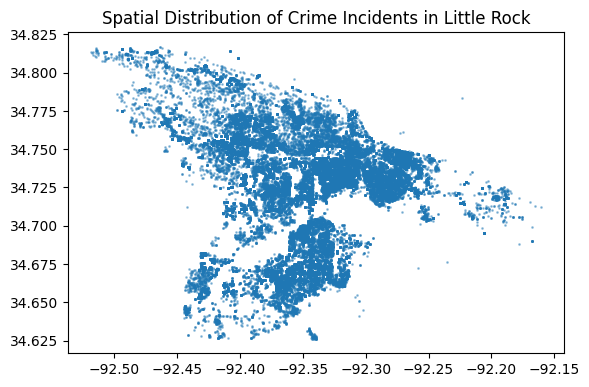

In [7]:
plt.figure(figsize=(10,10))
crime_gdf.plot(markersize=1, alpha=0.4)
plt.title("Spatial Distribution of Crime Incidents in Little Rock")
plt.show()

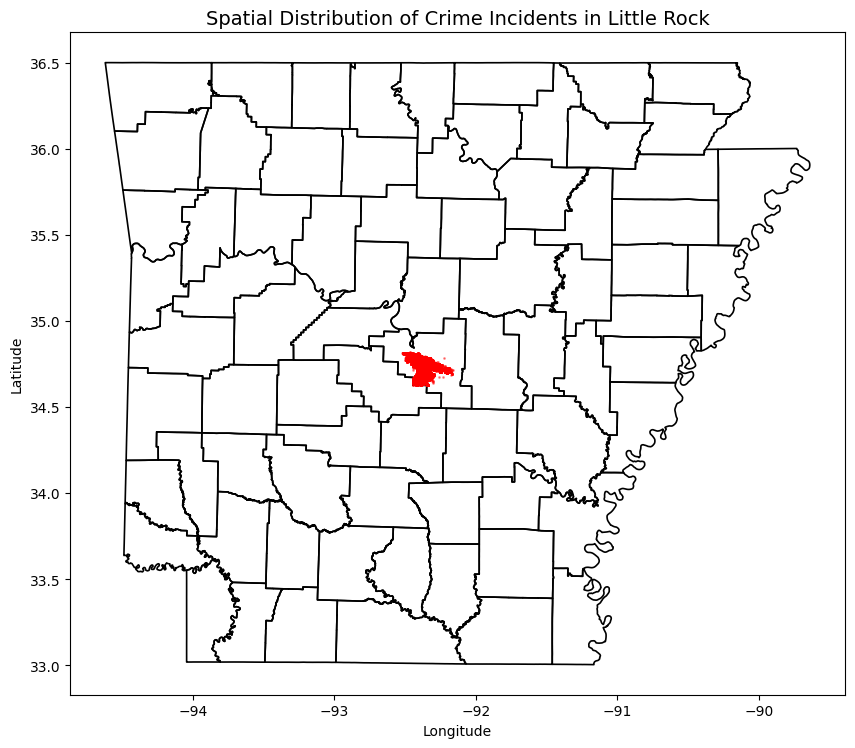

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read county boundary shapefile
county_gdf = gpd.read_file(r"D:\WesternMichiganUni\GIS_Programming\miniproject\COUNTY_BOUNDARY.shp")

# make sure both layers use same CRS
county_gdf = county_gdf.to_crs(crime_gdf.crs)

# plot county boundary first, then points
fig, ax = plt.subplots(figsize=(10, 10))

county_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)

crime_gdf.plot(
    ax=ax,
    markersize=1,
    alpha=0.4,
    color="red"
)

ax.set_title("Spatial Distribution of Crime Incidents in Little Rock", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [11]:
county_gdf.columns

Index(['OBJECTID', 'COUNTY', 'STATEFIPS', 'COUNTYFIPS', 'POP1900', 'POP1910',
       'POP1920', 'POP1930', 'POP1940', 'POP1950', 'POP1960', 'POP1970',
       'POP1980', 'POP1990', 'POP2000', 'POP2010', 'POP2020', 'EFF_DATE',
       'REV_DATE', 'REV_TYPE', 'SQ_MILES', 'Shape_STAr', 'Shape_STLe',
       'geometry'],
      dtype='object')

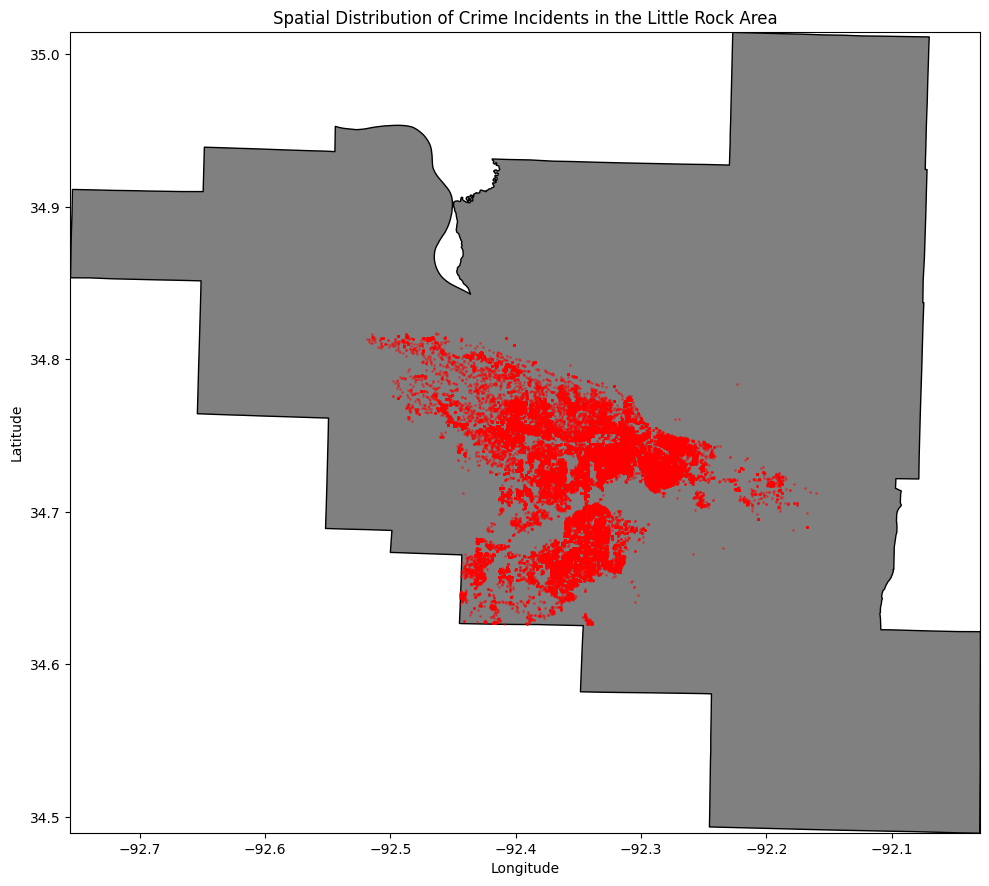

In [13]:

pulaski_gdf = county_gdf[county_gdf["COUNTY"].str.upper() == "PULASKI"].copy()
pulaski_gdf = pulaski_gdf.to_crs(crime_gdf.crs)
fig, ax = plt.subplots(figsize=(10, 10))

pulaski_gdf.plot(
    ax=ax,
    color="gray",
    edgecolor="black",
    linewidth=1
)

crime_gdf.plot(
    ax=ax,
    color="red",
    markersize=1,
    alpha=0.4
)

minx, miny, maxx, maxy = pulaski_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Spatial Distribution of Crime Incidents in the Little Rock Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [18]:
!pip show rtree pygeos

In [19]:
!pip install rtree

Defaulting to user installation because normal site-packages is not writeable


In [22]:
print(crime_gdf.columns)
print(pulaski_gdf.columns)

Index(['INCIDENT_DATE', 'INCIDENT_NUMBER', 'LOCATION_DISTRICT', 'OFFENSE_CODE',
       'OFFENSE_DESCRIPTION', 'WEAPON_TYPE', 'INCIDENT_LOCATION', 'CITY',
       'STATE', 'ZIP', 'LATITUDE', 'LONGITUDE', 'Location 1', 'Offense Status',
       'Year', 'CITY_CLEAN', 'STATE_CLEAN', 'Month', 'Month_Name', 'Hour',
       'DayOfWeek', 'Is_Weapon_Reported', 'Offense_Group', 'geometry',
       'index_right', 'OBJECTID', 'COUNTY', 'STATEFIPS', 'COUNTYFIPS',
       'POP1900', 'POP1910', 'POP1920', 'POP1930', 'POP1940', 'POP1950',
       'POP1960', 'POP1970', 'POP1980', 'POP1990', 'POP2000', 'POP2010',
       'POP2020', 'EFF_DATE', 'REV_DATE', 'REV_TYPE', 'SQ_MILES', 'Shape_STAr',
       'Shape_STLe'],
      dtype='object')
Index(['OBJECTID', 'COUNTY', 'STATEFIPS', 'COUNTYFIPS', 'POP1900', 'POP1910',
       'POP1920', 'POP1930', 'POP1940', 'POP1950', 'POP1960', 'POP1970',
       'POP1980', 'POP1990', 'POP2000', 'POP2010', 'POP2020', 'EFF_DATE',
       'REV_DATE', 'REV_TYPE', 'SQ_MILES', 'Shape_STAr

In [23]:
crime_gdf = crime_gdf.drop(columns=["index_right", "index_left"], errors="ignore")
pulaski_gdf = pulaski_gdf.drop(columns=["index_right", "index_left"], errors="ignore")

In [24]:
import geopandas as gpd

crime_gdf_county = gpd.sjoin(
    crime_gdf,
    pulaski_gdf,
    how="inner",
    predicate="within"
)

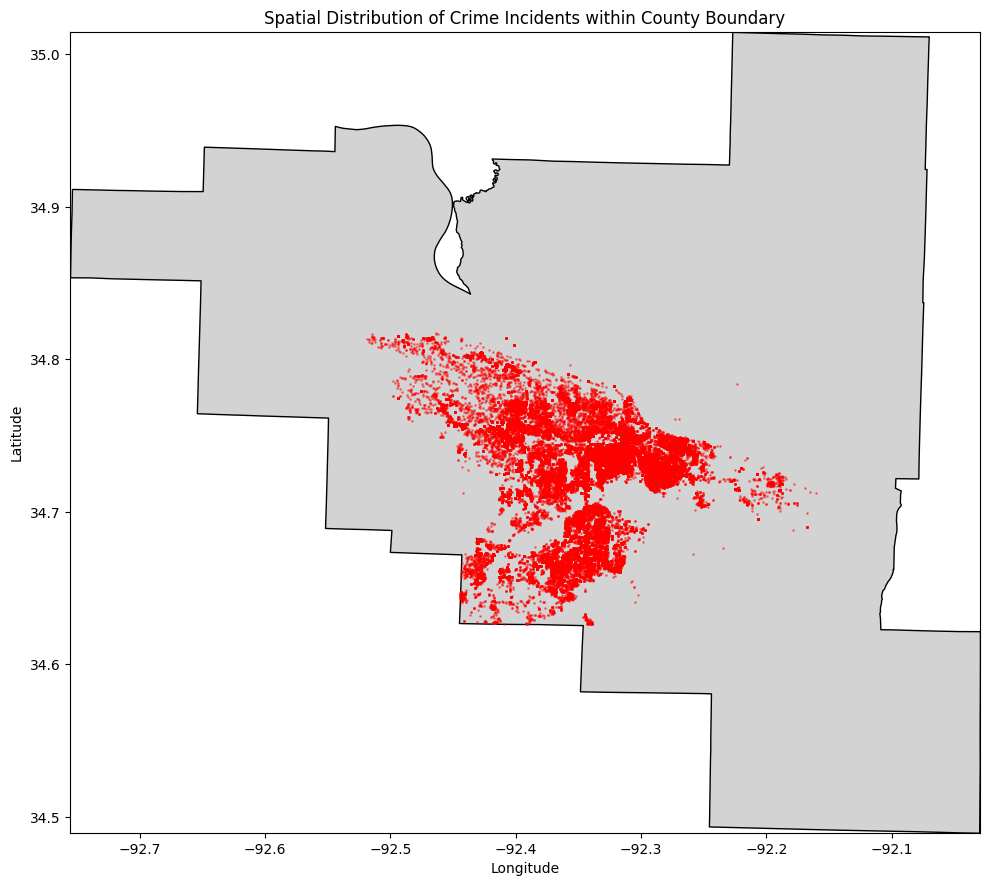

In [25]:
fig, ax = plt.subplots(figsize=(10, 10))

pulaski_gdf.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=1
)

crime_gdf_county.plot(
    ax=ax,
    color="red",
    markersize=1,
    alpha=0.4
)

minx, miny, maxx, maxy = pulaski_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Spatial Distribution of Crime Incidents within County Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [26]:
crime_df["CITY_CLEAN"] = crime_df["CITY"].astype(str).str.upper().str.strip()

crime_df_lr = crime_df[
    crime_df["CITY_CLEAN"].str.contains("LITTLE ROCK", na=False) |
    (crime_df["CITY_CLEAN"] == "LR")
].copy()

crime_gdf_lr = gpd.GeoDataFrame(
    crime_df_lr,
    geometry=gpd.points_from_xy(crime_df_lr["LONGITUDE"], crime_df_lr["LATITUDE"]),
    crs="EPSG:4326"
)

crime_gdf_lr = gpd.sjoin(
    crime_gdf_lr,
    pulaski_gdf,
    how="inner",
    predicate="within"
)

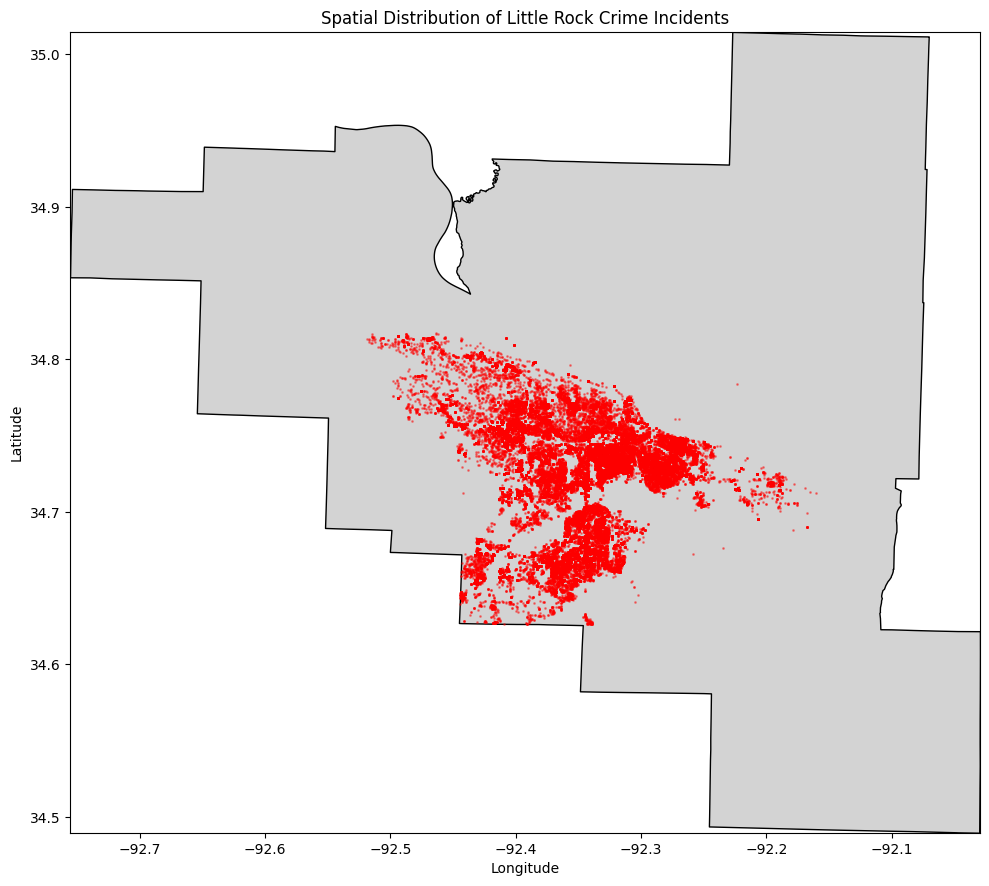

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

pulaski_gdf.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=1
)

crime_gdf_lr.plot(
    ax=ax,
    color="red",
    markersize=1,
    alpha=0.4
)

minx, miny, maxx, maxy = pulaski_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Spatial Distribution of Little Rock Crime Incidents")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Read the CSV File and Inspect the Data

### Data Quality Assessment and Missing Values

In [93]:
null_counts = crime_df.isnull().sum().sort_values(ascending=False)
null_percent = (crime_df.isnull().sum() / len(crime_df) * 100).sort_values(ascending=False)

null_summary = pd.DataFrame({
    "Null Count": null_counts,
    "Null Percent": null_percent
})

null_summary

,Null Count,Null Percent
WEAPON_TYPE,61168,75.425725
LONGITUDE,5157,6.359052
LATITUDE,5157,6.359052
Location 1,5157,6.359052
LOCATION_DISTRICT,113,0.139339
Offense Status,28,0.034527
INCIDENT_DATE,0,0.000000
INCIDENT_LOCATION,0,0.000000
OFFENSE_DESCRIPTION,0,0.000000
OFFENSE_CODE,0,0.000000


### Clean and Prepare the Dataset

In [94]:
# Convert date field to datetime
crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")

# Remove records without coordinates for spatial analysis
crime_df_clean = crime_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# Optional coordinate range filter to remove obvious spatial outliers
crime_df_clean = crime_df_clean[
    (crime_df_clean["LATITUDE"].between(34, 35)) &
    (crime_df_clean["LONGITUDE"].between(-93, -92))
].copy()

print("Original row count:", len(crime_df))
print("Cleaned row count:", len(crime_df_clean))

Original row count: 81097
Cleaned row count: 75795


### Create Derived Variables

In [95]:
crime_df_clean["Year"] = crime_df_clean["INCIDENT_DATE"].dt.year
crime_df_clean["Month"] = crime_df_clean["INCIDENT_DATE"].dt.month
crime_df_clean["Month_Name"] = crime_df_clean["INCIDENT_DATE"].dt.month_name()
crime_df_clean["Hour"] = crime_df_clean["INCIDENT_DATE"].dt.hour
crime_df_clean["DayOfWeek"] = crime_df_clean["INCIDENT_DATE"].dt.day_name()
crime_df_clean["Is_Weapon_Reported"] = crime_df_clean["WEAPON_TYPE"].notna()

### Create a Simplified Offense Classification

In [96]:
def classify_offense(offense):
    offense = str(offense).upper()
    if "ASSAULT" in offense:
        return "Assault"
    elif "LARCENY" in offense or "THEFT" in offense:
        return "Theft"
    elif "BURGLARY" in offense:
        return "Burglary"
    elif "ROBBERY" in offense:
        return "Robbery"
    elif "MOTOR VEHICLE" in offense:
        return "Vehicle Crime"
    elif "RAPE" in offense or "SEX" in offense:
        return "Sex Offense"
    else:
        return "Other"

crime_df_clean["Offense_Group"] = crime_df_clean["OFFENSE_DESCRIPTION"].apply(classify_offense)

crime_df_clean[["OFFENSE_DESCRIPTION", "Offense_Group"]].head()

,OFFENSE_DESCRIPTION,Offense_Group
532,ALL OTHER LARCENY,Theft
533,AGGRAVATED ASSAULT,Assault
534,ALL OTHER LARCENY,Theft
535,AGGRAVATED ASSAULT,Assault
536,AGGRAVATED ASSAULT,Assault


### Exploratory Summary Statistics

In [97]:
crime_df_clean.describe(include="all")

,INCIDENT_DATE,INCIDENT_NUMBER,LOCATION_DISTRICT,OFFENSE_CODE,OFFENSE_DESCRIPTION,WEAPON_TYPE,INCIDENT_LOCATION,CITY,STATE,ZIP,...,LONGITUDE,Location 1,Offense Status,Year,Month,Month_Name,Hour,DayOfWeek,Is_Weapon_Reported,Offense_Group
count,75795,75795,75700.000000,75795,75795,19739,75795,75795,75795,75795.000000,...,75795.000000,75795,75769,75795.000000,75795.000000,75795,75795.000000,75795,75795,75795
unique,NaN,69450,NaN,13,13,17,24697,1,1,NaN,...,NaN,23166,11,NaN,NaN,12,NaN,7,2,5
top,NaN,2024-113737,NaN,13A,AGGRAVATED ASSAULT,FIREARM,2700 S SHACKLEFORD RD,LITTLE ROCK,AR,NaN,...,NaN,"(34.728334, -92.397723)",OP,NaN,NaN,May,NaN,Monday,False,Theft
freq,NaN,30,NaN,17364,17364,5346,1420,75795,75795,NaN,...,NaN,1072,47249,NaN,NaN,6827,NaN,12244,56056,37246
mean,2022-11-12 23:37:14.871957504,NaN,66.956684,NaN,NaN,NaN,NaN,NaN,NaN,72205.151395,...,-92.349419,NaN,NaN,2022.361660,6.568045,NaN,12.797427,NaN,NaN,NaN
min,2020-01-01 00:01:00,NaN,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,72002.000000,...,-92.518661,NaN,NaN,2020.000000,1.000000,NaN,0.000000,NaN,NaN,NaN
25%,2021-06-14 13:51:30,NaN,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,72204.000000,...,-92.387085,NaN,NaN,2021.000000,4.000000,NaN,9.000000,NaN,NaN,NaN
50%,2022-10-20 07:58:00,NaN,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,72206.000000,...,-92.348033,NaN,NaN,2022.000000,7.000000,NaN,13.000000,NaN,NaN,NaN
75%,2024-04-17 17:32:30,NaN,81.000000,NaN,NaN,NaN,NaN,NaN,NaN,72209.000000,...,-92.318116,NaN,NaN,2024.000000,9.000000,NaN,17.000000,NaN,NaN,NaN
max,2025-12-31 23:01:00,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,72227.000000,...,-92.160271,NaN,NaN,2025.000000,12.000000,NaN,23.000000,NaN,NaN,NaN


### Visualization 1: Crime Incidents by Year

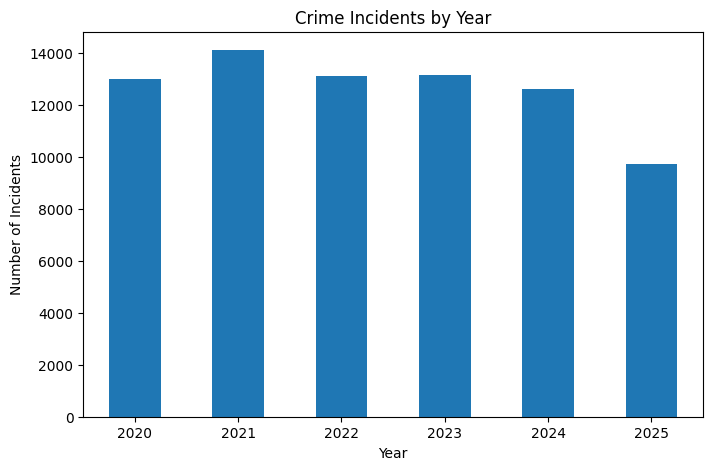

In [98]:
year_counts = crime_df_clean["Year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
year_counts.plot(kind="bar")
plt.title("Crime Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.show()

### Visualization 2: Top 10 Offense Descriptions

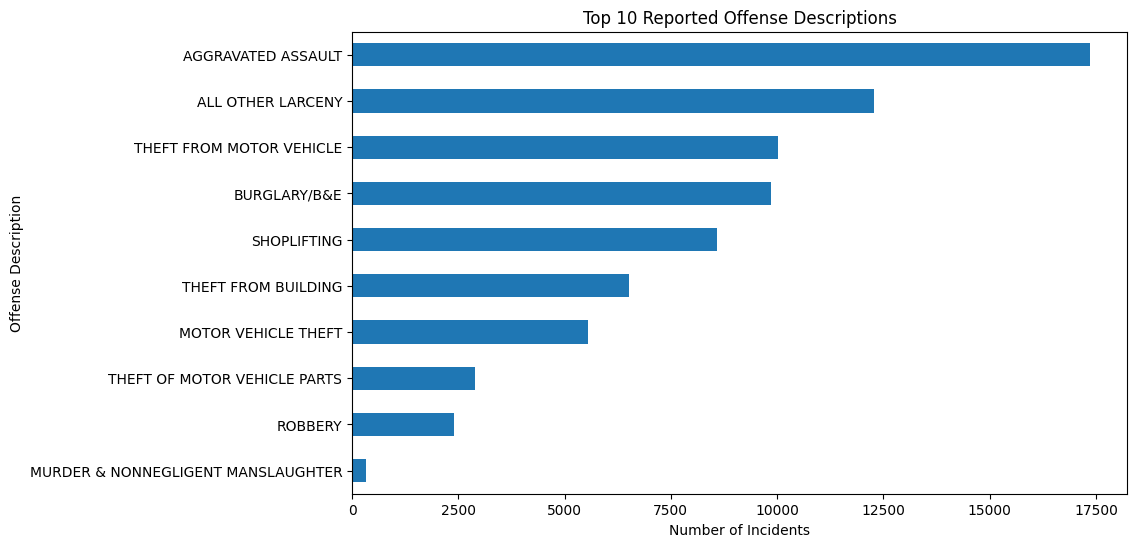

In [99]:
top_offenses = crime_df_clean["OFFENSE_DESCRIPTION"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_offenses.sort_values().plot(kind="barh")
plt.title("Top 10 Reported Offense Descriptions")
plt.xlabel("Number of Incidents")
plt.ylabel("Offense Description")
plt.show()

### Visualization 3: Crime Incidents by Hour of Day

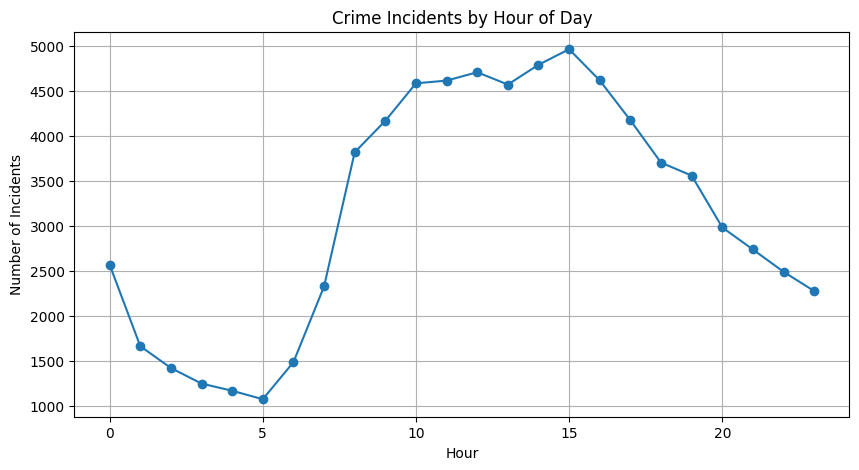

In [100]:
hour_counts = crime_df_clean["Hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind="line", marker="o")
plt.title("Crime Incidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Incidents")
plt.grid(True)
plt.show()

### Visualization 4: Crime Incidents by Day of Week

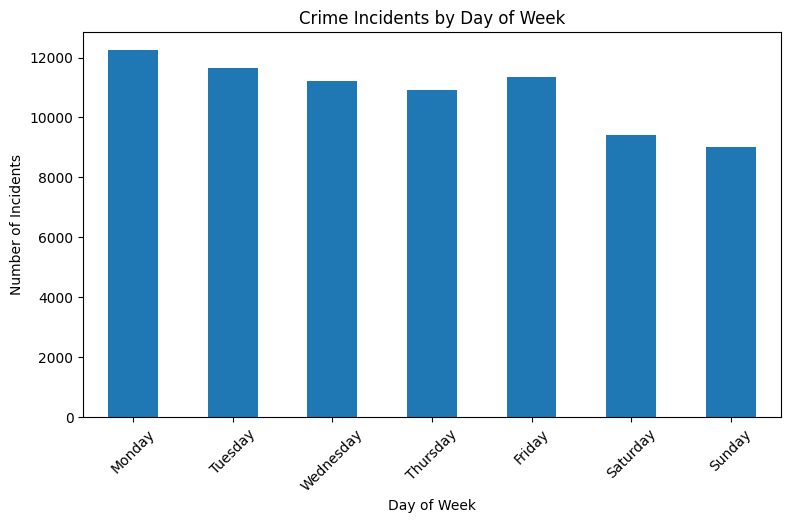

In [101]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = crime_df_clean["DayOfWeek"].value_counts().reindex(day_order)

plt.figure(figsize=(9,5))
day_counts.plot(kind="bar")
plt.title("Crime Incidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.show()

### Visualization 5: Simplified Offense Groups

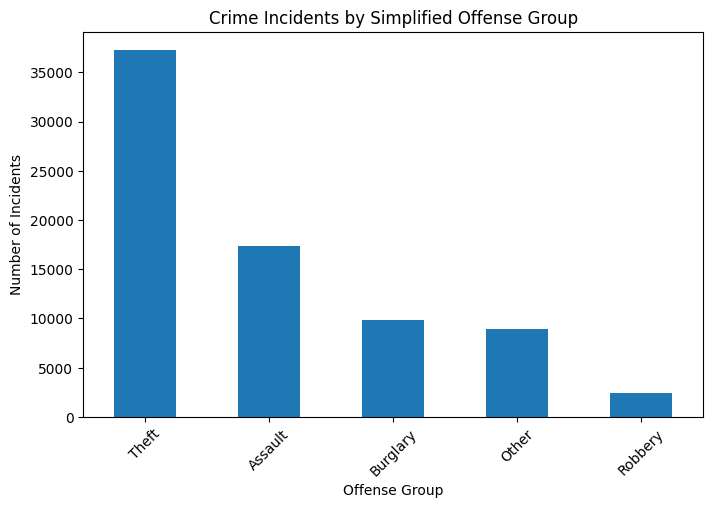

In [102]:
group_counts = crime_df_clean["Offense_Group"].value_counts()

plt.figure(figsize=(8,5))
group_counts.plot(kind="bar")
plt.title("Crime Incidents by Simplified Offense Group")
plt.xlabel("Offense Group")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.show()

### Convert the Cleaned DataFrame to a GeoDataFrame

In [103]:
geometry = gpd.points_from_xy(crime_df_clean["LONGITUDE"], crime_df_clean["LATITUDE"])

crime_gdf = gpd.GeoDataFrame(
    crime_df_clean,
    geometry=geometry,
    crs="EPSG:4326"
)

crime_gdf.head()

,INCIDENT_DATE,INCIDENT_NUMBER,LOCATION_DISTRICT,OFFENSE_CODE,OFFENSE_DESCRIPTION,WEAPON_TYPE,INCIDENT_LOCATION,CITY,STATE,ZIP,...,Location 1,Offense Status,Year,Month,Month_Name,Hour,DayOfWeek,Is_Weapon_Reported,Offense_Group,geometry
532,2025-12-31 23:01:00,2025-161160,53.0,23H,ALL OTHER LARCENY,NaN,2009 S WOODROW ST,LITTLE ROCK,AR,72204,...,"(34.731991, -92.305879)",OP,2025,12,December,23,Wednesday,False,Theft,POINT (-92.30588 34.73199)
533,2025-12-31 21:11:00,2025-161106,52.0,13A,AGGRAVATED ASSAULT,FIREARM,1624 BROADWAY ST,LITTLE ROCK,AR,72206,...,"(34.73349, -92.27864)",OP,2025,12,December,21,Wednesday,True,Assault,POINT (-92.27864 34.73349)
534,2025-12-31 20:05:00,2025-161075,82.0,23H,ALL OTHER LARCENY,NaN,6420 BASELINE RD,LITTLE ROCK,AR,72209,...,"(34.668983, -92.332351)",OP,2025,12,December,20,Wednesday,False,Theft,POINT (-92.33235 34.66898)
535,2025-12-31 18:52:00,2025-161039,82.0,13A,AGGRAVATED ASSAULT,KNIFE/CUTTING INSTRUMENT,8107 GEYER SPRINGS RD,LITTLE ROCK,AR,72209,...,"(34.676117, -92.343513)",OP,2025,12,December,18,Wednesday,True,Assault,POINT (-92.34351 34.67612)
536,2025-12-31 18:18:00,2025-161025,72.0,13A,AGGRAVATED ASSAULT,"PERSONAL WEAPONS (HANDS, FISTS, ETC)",11501 FINANCIAL CENTRE PKY,LITTLE ROCK,AR,72211,...,"(34.746082, -92.401722)",AJ,2025,12,December,18,Wednesday,True,Assault,POINT (-92.40172 34.74608)


In [104]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

crime_df = pd.read_csv(r"D:\WesternMichiganUni\GIS_Programming\miniproject\Little_Rock_Crime_2020_2026.csv")
crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")
crime_df["Year"] = crime_df["INCIDENT_DATE"].dt.year

# remove incomplete year
crime_df = crime_df[crime_df["Year"] != 2026].copy()

# remove rows without coordinates
crime_df = crime_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

# create GeoDataFrame
crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["LONGITUDE"], crime_df["LATITUDE"]),
    crs="EPSG:4326"
)

# read county boundary shapefile
county_gdf = gpd.read_file(r"D:\WesternMichiganUni\GIS_Programming\miniproject\COUNTY_BOUNDARY.shp").to_crs(crime_gdf.crs)

# keep only points within county
crime_gdf_county = gpd.sjoin(
    crime_gdf,
    county_gdf,
    how="inner",
    predicate="within"
)

print("Before county filter:", len(crime_gdf))
print("After county filter:", len(crime_gdf_county))

C:\Users\tangi\AppData\Local\Temp\ipykernel_27396\572400372.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df["INCIDENT_DATE"] = pd.to_datetime(crime_df["INCIDENT_DATE"], errors="coerce")


Before county filter: 75940
After county filter: 75795


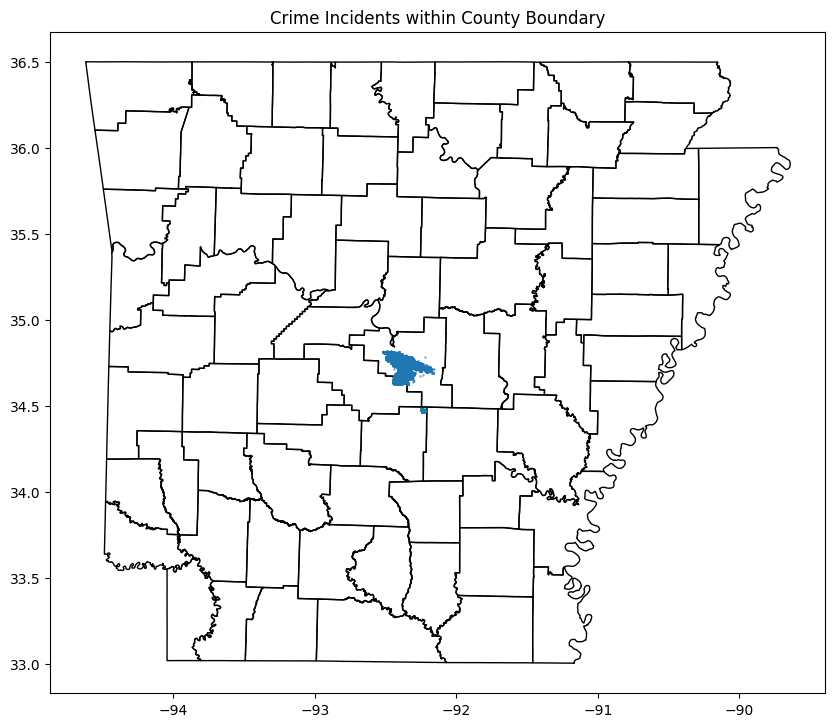

In [105]:
ax = county_gdf.plot(figsize=(10,10), facecolor="none", edgecolor="black")
crime_gdf_county.plot(ax=ax, markersize=1, alpha=0.4)
plt.title("Crime Incidents within County Boundary")
plt.show()

In [106]:
crime_df["CITY_CLEAN"] = crime_df["CITY"].astype(str).str.upper().str.strip()

crime_df = crime_df[
    crime_df["CITY_CLEAN"].str.contains("LITTLE ROCK", na=False) |
    (crime_df["CITY_CLEAN"] == "LR")
].copy()